<a href="https://colab.research.google.com/github/poosathanusri06/CodeAlpha_internshipwork/blob/main/TASK4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. RUNNING SENTIMENT ANALYSIS (VADER NLP)

Sample Analyzed Dataset:
                                         Review_Text  Compound_Score  \
0  This product is absolutely amazing! Highly rec...          0.8147   
1  Worst purchase I have ever made. Broke within ...         -0.7845   
2  It works okay, nothing special but gets the jo...         -0.0462   
3  Excellent build quality and superb customer se...          0.8439   
4  Terrible experience. The item arrived damaged ...         -0.7184   

  Sentiment_Label  
0        Positive  
1        Negative  
2         Neutral  
3        Positive  
4        Negative  

Overall Sentiment Breakdown:
Sentiment_Label
Positive    10
Negative     7
Neutral      3
Name: count, dtype: int64

2. GENERATING SENTIMENT VISUALIZATIONS


/tmp/ipykernel_2692/844741172.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment_Label', palette=palette, ax=axes[0], order=['Positive', 'Neutral', 'Negative'])
/tmp/ipykernel_2692/844741172.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sentiment, x='Product_Category', y='Compound_Score', palette='Blues_d', ax=axes[1])


Sentiment dashboard visual saved as 'sentiment_analysis_dashboard.png'.


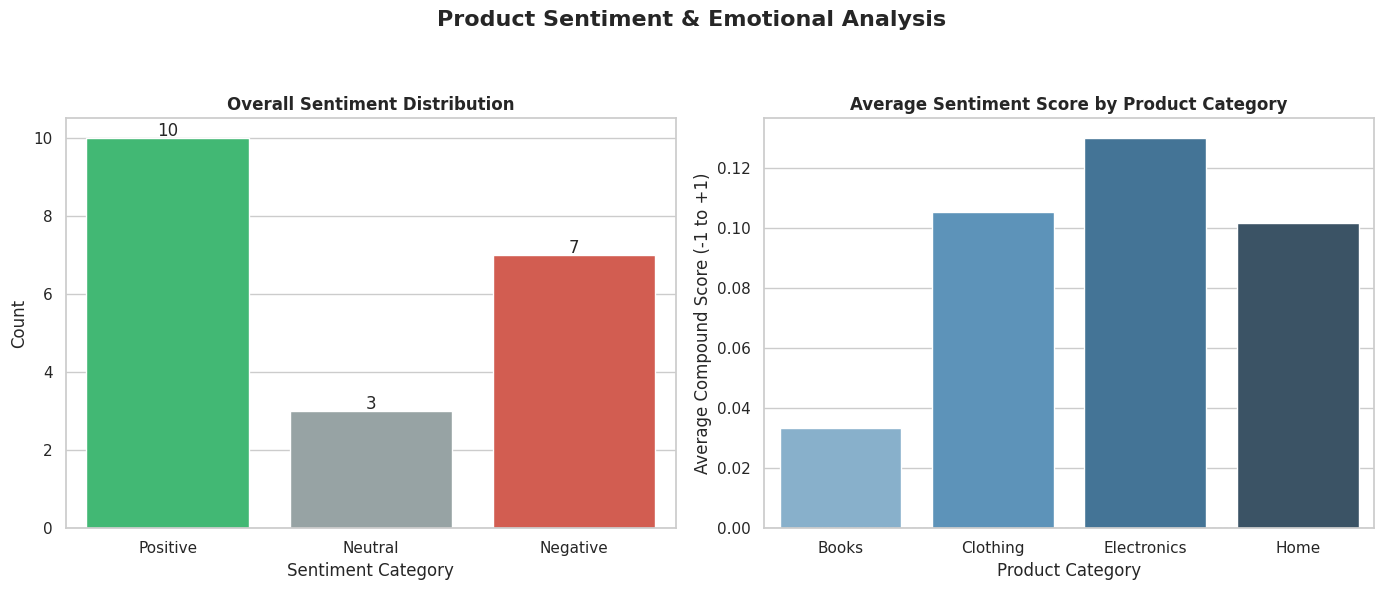

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download the required VADER lexicon
nltk.download('vader_lexicon', quiet=True)

# Set style for plots
sns.set_theme(style="whitegrid")

def generate_review_data():
    """Generates synthetic product review data for sentiment analysis."""
    data = {
        'ReviewID': range(101, 121),
        'Product_Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Electronics',
                             'Clothing', 'Home', 'Books', 'Electronics', 'Books'] * 2,
        'Review_Text': [
            "This product is absolutely amazing! Highly recommend it.",
            "Worst purchase I have ever made. Broke within two days.",
            "It works okay, nothing special but gets the job done.",
            "Excellent build quality and superb customer service!",
            "Terrible experience. The item arrived damaged and late.",
            "Decent item for the price. I am satisfied.",
            "Complete waste of money. Do not buy this!",
            "I love this book! It changed my perspective completely.",
            "The product is fine, but the shipping was really slow.",
            "Fantastic quality! Exceeded all my expectations.",
            "Very poor design. Extremely difficult to use.",
            "Average quality, works as expected.",
            "Incredible performance and sleek design!",
            "Horrible product. Stopped working after one week.",
            "Pretty good overall, though it could be a bit cheaper.",
            "Truly outstanding experience from start to finish.",
            "Not bad, but I have seen better products in this price range.",
            "Disappointing quality. Would not recommend to anyone.",
            "Superb value for money! Very happy with this purchase.",
            "It is acceptable. Neither great nor terrible."
        ]
    }
    return pd.DataFrame(data)

def perform_sentiment_analysis(df):
    """Applies VADER NLP lexicon to analyze sentiment and classify text."""
    print("=" * 50)
    print("1. RUNNING SENTIMENT ANALYSIS (VADER NLP)")
    print("=" * 50)

    sia = SentimentIntensityAnalyzer()

    # Calculate polarity scores
    df['Compound_Score'] = df['Review_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])
    df['Positive_Score'] = df['Review_Text'].apply(lambda x: sia.polarity_scores(x)['pos'])
    df['Negative_Score'] = df['Review_Text'].apply(lambda x: sia.polarity_scores(x)['neg'])
    df['Neutral_Score']  = df['Review_Text'].apply(lambda x: sia.polarity_scores(x)['neu'])

    # Classify based on compound score thresholds
    def classify_sentiment(score):
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

    df['Sentiment_Label'] = df['Compound_Score'].apply(classify_sentiment)

    print("\nSample Analyzed Dataset:")
    print(df[['Review_Text', 'Compound_Score', 'Sentiment_Label']].head())

    print("\nOverall Sentiment Breakdown:")
    print(df['Sentiment_Label'].value_counts())

    return df

def visualize_sentiment_insights(df):
    """Generates visualizations for sentiment patterns across categories."""
    print("\n" + "=" * 50)
    print("2. GENERATING SENTIMENT VISUALIZATIONS")
    print("=" * 50)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Product Sentiment & Emotional Analysis", fontsize=16, fontweight='bold')

    # Chart 1: Sentiment Distribution (Count Plot)
    palette = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
    sns.countplot(data=df, x='Sentiment_Label', palette=palette, ax=axes[0], order=['Positive', 'Neutral', 'Negative'])
    axes[0].set_title("Overall Sentiment Distribution", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Sentiment Category")
    axes[0].set_ylabel("Count")

    # Add data labels
    for p in axes[0].patches:
        axes[0].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

    # Chart 2: Average Sentiment Score by Category
    category_sentiment = df.groupby('Product_Category')['Compound_Score'].mean().reset_index()
    sns.barplot(data=category_sentiment, x='Product_Category', y='Compound_Score', palette='Blues_d', ax=axes[1])
    axes[1].set_title("Average Sentiment Score by Product Category", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Product Category")
    axes[1].set_ylabel("Average Compound Score (-1 to +1)")
    axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig('sentiment_analysis_dashboard.png', dpi=300)
    print("Sentiment dashboard visual saved as 'sentiment_analysis_dashboard.png'.")
    plt.show()

if __name__ == "__main__":
    review_df = generate_review_data()
    analyzed_df = perform_sentiment_analysis(review_df)
    visualize_sentiment_insights(analyzed_df)